Are we misusing LLM context windows? How can we do more with smaller and cheaper models? 

This started off as a hypothesis, but turned into something I built and tested.

\[Wednesday, May 20, 2026]

Are we misusing LLM context windows? How can we do more with smaller and cheaper models? 

This started off as a hypothesis, but turned into something I built and tested.

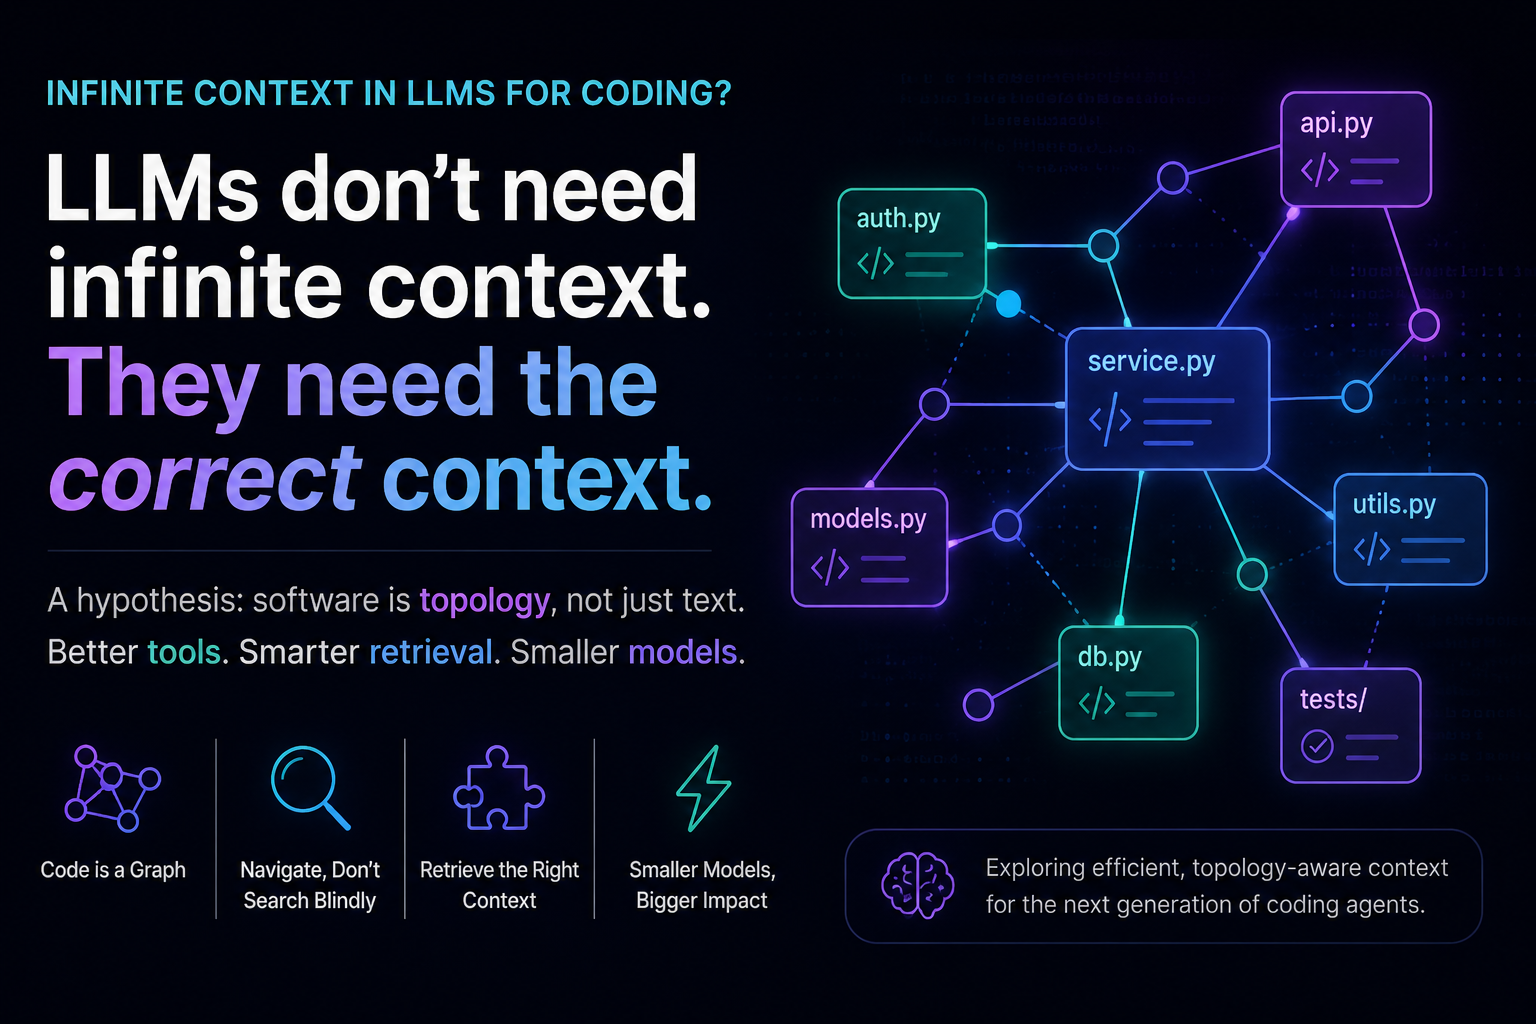
<p class="text-center italic">Image generated by ChatGPT as a visualization.</p>

## The Driver: humans ain't the smartest. Yet...

We built:

* operating systems
* databases
* rockets
* compilers
* the internet
* HFT systems
* CAD kernels

All this, while our brains literally sip just 20 watts.

Yet, we're talking about building terawatt-scale datacenters.

This was the elephant in the room which got me realizing that programming is *not* bottlenecked by raw intelligence or remembering everything. Instead, it's a problem solved through:

* Navigation
* JIT context assembly and relying on our goldfish-style memory to forget unimportant details quickly
* Docs
* Search
* Notes
* Architecture patterns

## LLM Context: the problem & flawed assumptions

Many modern coding agents treat codebases primarily as large collections of text to search and repeatedly summarize.

This creates an implicit assumption that code retrieval is mostly a text retrieval problem. **I believe this assumption is incomplete and should be deleted.**

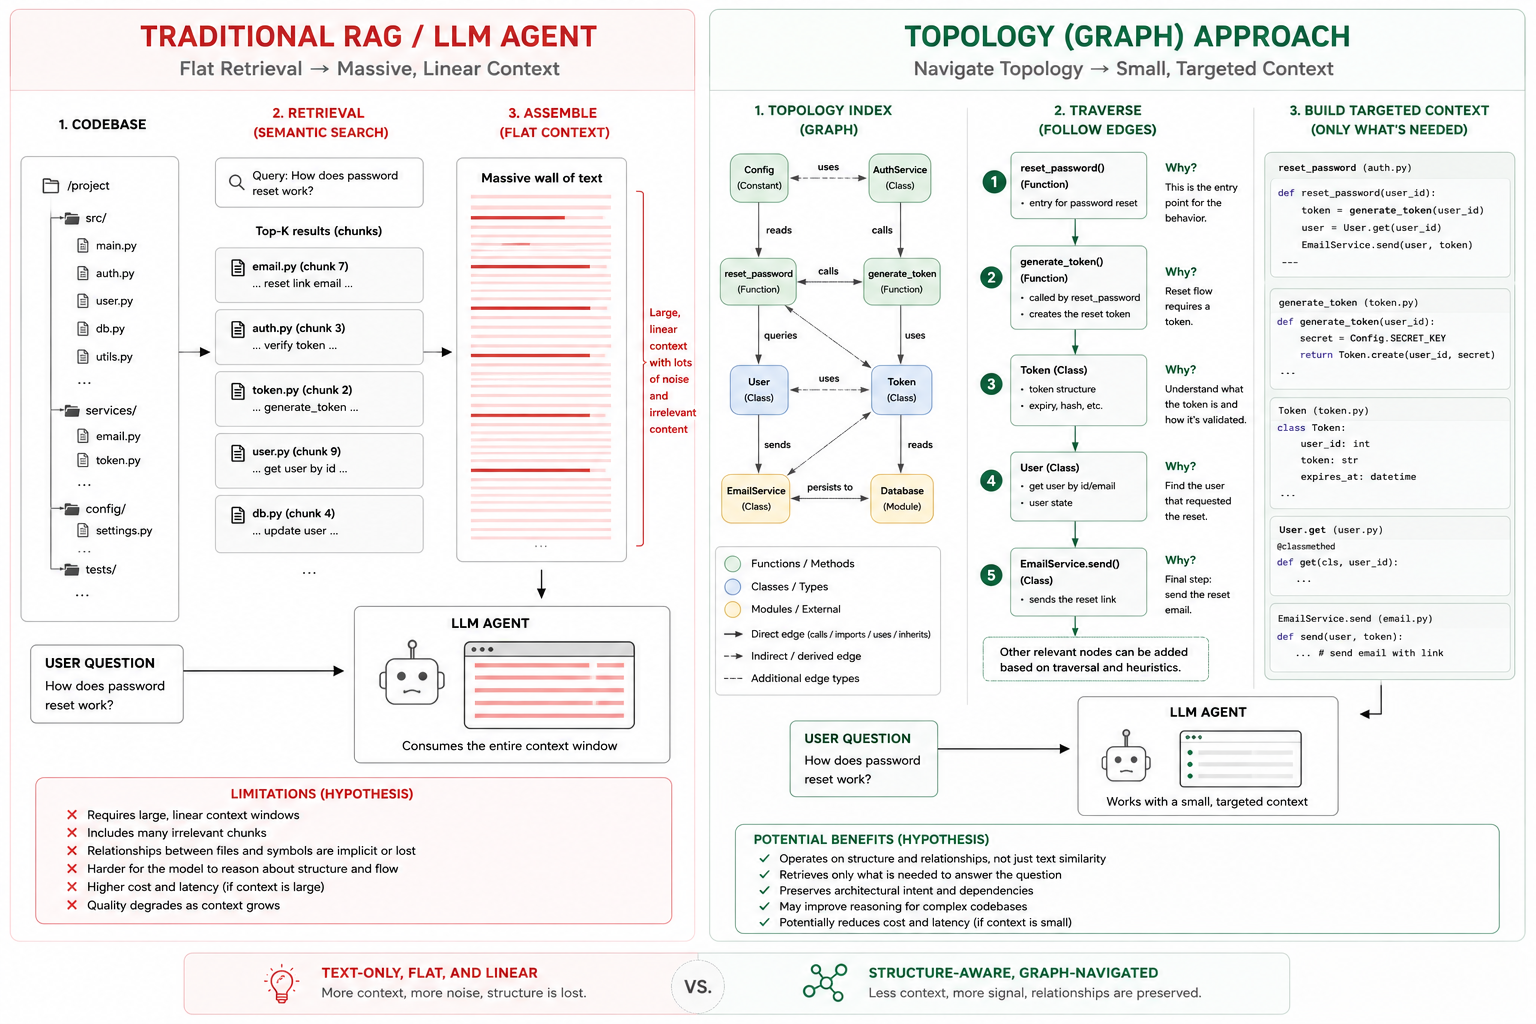
<p class="text-center italic">Image generated by ChatGPT as a visualization.</p>

## Topology & Manifolds

Code isn't just a wall of text. It's a directed graph of interconnected nodes

Most code today:

```
constants
functions
classes
    constants
    functions
    classes
        ... this recurses
```

In distributed systems:

```
[A] -> [B] -> [C (external-facing API)]
        |
        V
       [X]
```

But even in distributed systems, this distributed connectivity is tightly defined and builds a traceable surface:

```
A:
class
    function
        apiClientB::hello_world()
            fetch("/hello_world");

B:
class: Controller
    [Route("/hello_world")]
    function
        return "leave me alone pls"
```

Because of this, I increasingly view software topology as behaving like a watertight manifold:
* functionality rarely exists in isolation
* there is almost always a traversable path connecting behavior back to its origin
* (I'm not a Ph.D, just a dumbass with a computer and a bit of intuition so might be wrong here)

> Manifold
> : A manifold is a shape or space where nearby things tend to stay connected in predictable ways, even if the overall system is very large or complicated (Source: ChatGPT, since I suck at explaining math)
> : [Wikipedia](https://en.wikipedia.org/wiki/Manifold)

In fact, UML and similar standards literally define certain types of connectivity graphs.

## The Hypothesis

**LLMs don't need inifinite context in codebases. They need the *correct* context**.

We can rely on the graph behavior and natural organization of code to efficiently and cheaply provide large context access to LLMs. By doing this, we can allow smaller models to operate at levels similar to larger models without a significant drop in accuracy.

## How

How
: Build tooling which hands LLMs the topology of the code so they don't need to build it into their context

Eventually
: Shrink context windows of LLMs and train the models to more efficiently navigate through the topology of code using these tools

### Why?

* languages rely on strongly defined ASTs (abstract syntax trees) to navigate through code fast enough to compile or interpret code.
* the existence and widespread adoption of UML and related modeling systems
    * literally exist specifically to represent topology in software and distributed systems.
    * Though this argument is a bit of a chicken-and-the-egg.

There are real-life examples of this too:
* Clang (C/C++/ObjC/ObjC++) [maskray.me](https://maskray.me/blog/2023-09-24-a-deep-dive-into-clang-source-file-compilation)
* v8 (js) [v8.dev first party docs](https://v8.dev/blog/background-compilation)

## Conclusion

Software is not just text. It is topology. It is connectivity. It is traversable structure.

Modern coding agents repeatedly reconstruct this structure through brute force context windows, summarization, and text retrieval. I believe this is the wrong abstraction layer.

We don't memorize entire codebases. We navigate through them, with the help of our IDEs, docs, and understanding the architecture.

Compilers, interpreters, IDEs, static analyzers, and linkers already rely heavily on the fact that software is structured and machine traversable. Modern coding agents should too.

This started off with me facing the pain of being too broke to afford Opus 4.7 in Claude Code. Then it turned into a hypothesis:

> What if smaller and cheaper models could become significantly more capable simply by navigating software topology more efficiently?

So I built a prototype.

In the next article, I’ll cover:

* topology extraction
* graph indexing
* why I chose LMDB
* where the prototype failed
* and what happened when I tried this against a real codebase

## What's Next

[See my implementation](https://github.com/yash101/hyperquery)

I'm further along on this journey than this article suggests, but I'm slow at writing. But here's a list of what to expect and what I have already learned:

1. The prototype - why it worked and why it didn't.
2. Improving the prototype to make it more functional
3. Where the original premise was right and wrong (and yes, this hypothesis is wrong in subtle ways)
4. Best of both worlds: a hybrid architecture
5. Why retrieval is only 30% of the problem, and what the other 70% is